# Filtering thresholds, RS and NATIM

Distributions and yields for the criteria, from the unfiltered files.

| criterion | keep | threshold |
|---|---|---|
| `FR_computed` | above | 1.0 Hz |
| `ann_line_noise_50Hz` | below | 0.7 |
| `ann_line_noise_60Hz` | below | 0.7 |
| `presence_ratio_computed` | above | 0.75 |
| `ann_waveform_SNR` (old, SpikeInterface) | above | 2 |
| `wf_snr_computed` (new, peak-to-peak / residual) | above | 4 |
| `viol_ratio_1p5ms` | below | 1.5 |
| `coinc_ratio_worst` | below | 10.0 |

`wf_shape_pc1_modesep` is computed and reported below, but is **not** applied as
a criterion. Its distribution is shown in section 3.2 so it can still be
inspected, and it is stored in the filtered files as a diagnostic.

**Two SNR criteria now, not one.** `ann_waveform_SNR` is the annotation
inherited from the source file - SpikeInterface's built-in `snr` metric,
amplitude at the extremum sample divided by the per-channel background noise
level estimated from the continuous raw trace. `wf_snr_computed` is this
pipeline's own metric - template peak-to-peak amplitude divided by the SD of
each spike's residual from the mean template, i.e. an isolation/consistency
measure rather than a classical amplitude-vs-noise-floor SNR. They are not on
a comparable absolute scale, so don't expect the two threshold numbers (2.0
and 4.0) to mean the same thing in isolation - section 6 checks directly how
much the two criteria disagree and where.

**Why `viol_ratio_1p5ms` rather than `viol_ratio_min`.** The minimum was taken
across a grid starting at 1 ms, and at that shortest window almost no unit has
any interval, so the ratio was exactly zero for essentially every unit: 4363 of
4363 in RS had their minimum at the first grid point. Taking the minimum was the
wrong summary. The value at the conventional 1.5 ms window is well behaved,
median 0.095 in RS and 0.109 in NATIM, and it is what the synthetic calibration
measured, so the reference values apply to it directly.

**A note on the firing rate criterion.** At 1 Hz it does more than remove
low-rate units. The refractory metric is undefined below 100 spikes and the
shape metric below 200, so those units were previously being removed three times
over, once by each criterion, and the accounting attributed spike-count
exclusions to contamination. With a rate threshold at 1 Hz almost every such
unit is removed by the rate criterion itself, which section 3 verifies.

In [1]:
import os
os.chdir('/CSNG/studekat/ripple_paper_clean_copy/code')

In [2]:
from functions_analysis import *
import pandas as pd, numpy as np, yaml, pickle
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

with open("/CSNG/studekat/ripple_paper_clean_copy/code/params_analysis.yml") as f:
    P = yaml.safe_load(f)

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy/dataframes'
CONDITIONS = {'RS': ['L','N','F'], 'NATIM': ['N','F']}
COL = {'RS': 'tab:green', 'NATIM': 'tab:purple'}

## 1. Load

In [3]:
def load(type_rec, monkeys):
    dfs = []
    for m in monkeys:
        for date in P['dates'][m][type_rec]:
            p = f'{DF_FOLDER}/filter_metrics_{type_rec}/monkey{m}_all_arrays_date_{date}.pkl'
            try:
                with open(p,'rb') as f: dfs.append(pickle.load(f))
            except Exception:
                pass
    if not dfs: return None
    d = pd.concat(dfs, ignore_index=True)
    d['condition'] = type_rec
    return d

DATA = {}
for tr, mks in CONDITIONS.items():
    d = load(tr, mks)
    if d is None:
        print(f'{tr}: nothing found'); continue
    DATA[tr] = d
    print(f'{tr}: {d.shape[0]} units, {d.groupby(["monkey","date"]).ngroups} recordings')

RS: 11377 units, 7 recordings
NATIM: 100462 units, 45 recordings


## 2. The criteria

`FR_computed` is listed first because it is applied first: it removes the units
for which the refractory and shape metrics are undefined.

### 2.1 The two SNR thresholds

`ann_waveform_SNR` (old, inherited SpikeInterface annotation) and
`wf_snr_computed` (new, peak-to-peak / residual based) are absolute
thresholds, same as every other criterion in this notebook: keep above 2.0
for the old metric, above 4.0 for the new one. They are not on a comparable
scale (see the note at the top), so don't read anything into the fact that
the two numbers differ - that's expected, not a typo.

In [4]:
# columns actually available - confirm 'ann_waveform_SNR' is the right name
pooled = pd.concat(DATA.values(), ignore_index=True) if DATA else pd.DataFrame()
snr_cols = [c for c in pooled.columns if 'snr' in c.lower()]
print('columns containing "snr":', snr_cols)

# --- fixed thresholds ---
SNR_THRESH = {
    'ann_waveform_SNR': 2.0,   # old, SpikeInterface-computed
    'wf_snr_computed':  4.0,   # new, peak-to-peak / residual based
}
for col, th in SNR_THRESH.items():
    if col not in pooled.columns:
        print(f'{col}: NOT FOUND in the loaded dataframes - fix the column name above')
    else:
        v = pooled[col].replace([np.inf, -np.inf], np.nan).dropna()
        kept = 100 * (v >= th).mean()
        print(f'{col:20s} threshold={th:<6} keeps {kept:.1f}% pooled (n={len(v)})')

columns containing "snr": ['ann_waveform_SNR', 'wf_snr_computed']
ann_waveform_SNR     threshold=2.0    keeps 60.6% pooled (n=111839)
wf_snr_computed      threshold=4.0    keeps 50.2% pooled (n=111837)


In [5]:
CRIT = {
    'FR_computed':             ('above', 1.0,  'firing rate [Hz]'),
    'ann_line_noise_50Hz':     ('below', 0.7,  'line noise 50 Hz'),
    'ann_line_noise_60Hz':     ('below', 0.7,  'line noise 60 Hz'),
    'presence_ratio_computed': ('above', 0.75, 'presence ratio'),
    'ann_waveform_SNR':        ('above', SNR_THRESH.get('ann_waveform_SNR', 2),
                                 'waveform SNR (old, SpikeInterface)'),
    'wf_snr_computed':         ('above', SNR_THRESH.get('wf_snr_computed', 4),
                                 'waveform SNR (new, peak-to-peak / residual)'),
    'viol_ratio_1p5ms':        ('below', 1.5,  'refractory violation ratio at 1.5 ms'),
    'coinc_ratio_worst':       ('below', 10.0, 'cross-unit coincidence'),
}

# computed and reported, but not applied as a criterion
REPORTED = {
    'wf_shape_pc1_modesep': ('below', 5.0, 'waveform shape heterogeneity'),
}

# plotting ranges, since the automatic percentile clipping fails on metrics
# that are bounded at zero with a long tail
RANGES = {
    'FR_computed':             (0.0, 40.0),
    'ann_line_noise_50Hz':     (-0.25, 0.9),
    'ann_line_noise_60Hz':     (-0.25, 0.9),
    'presence_ratio_computed': (0.0, 1.0),
    'ann_waveform_SNR':        (0.0, 30.0),
    'wf_snr_computed':         (0.0, 30.0),
    'viol_ratio_1p5ms':        (0.0, 1.5),     # 1.0 is violations at chance
    'wf_shape_pc1_modesep':    (0.0, 10.0),
    'coinc_ratio_worst':       (0.0, 60.0),    # 1.0 is chance
}

print('quantiles per condition:')
for col, (direc, th, name) in CRIT.items():
    print(f'\n{name}  ({col})  KEEP {direc} {th}')
    for tr, d in DATA.items():
        if col not in d.columns:
            print(f'   {tr}: absent'); continue
        v = d[col].replace([np.inf,-np.inf], np.nan).dropna()
        if not len(v):
            print(f'   {tr}: all NaN'); continue
        q = v.quantile([.05,.25,.5,.75,.95]).round(4)
        kept = (v <= th) if direc == 'below' else (v >= th)
        print(f'   {tr:6s} n={len(v):6d} NaN={int(d[col].isna().sum()):5d}  '
              f'p05 {q.iloc[0]:7.3f}  med {q.iloc[2]:7.3f}  p95 {q.iloc[4]:8.3f}  '
              f'-> keeps {100*kept.mean():5.1f}%')

quantiles per condition:

firing rate [Hz]  (FR_computed)  KEEP above 1.0
   RS     n= 11377 NaN=    0  p05   4.139  med  19.292  p95   75.282  -> keeps  98.5%
   NATIM  n=100462 NaN=    0  p05   2.457  med  20.329  p95   73.901  -> keeps  97.7%

line noise 50 Hz  (ann_line_noise_50Hz)  KEEP below 0.7
   RS     n= 11377 NaN=    0  p05  -0.102  med   0.239  p95    0.471  -> keeps  99.8%
   NATIM  n=100462 NaN=    0  p05  -0.073  med   0.305  p95    0.492  -> keeps  99.8%

line noise 60 Hz  (ann_line_noise_60Hz)  KEEP below 0.7
   RS     n= 11377 NaN=    0  p05  -0.102  med   0.299  p95    0.568  -> keeps  99.8%
   NATIM  n=100462 NaN=    0  p05  -0.072  med   0.395  p95    0.596  -> keeps  98.7%

presence ratio  (presence_ratio_computed)  KEEP above 0.75
   RS     n= 11377 NaN=    0  p05   1.000  med   1.000  p95    1.000  -> keeps  99.6%
   NATIM  n=100462 NaN=    0  p05   1.000  med   1.000  p95    1.000  -> keeps  99.4%

waveform SNR (old, SpikeInterface)  (ann_waveform_SNR)  KEEP ab

## 3. Distributions, green shading is what is kept

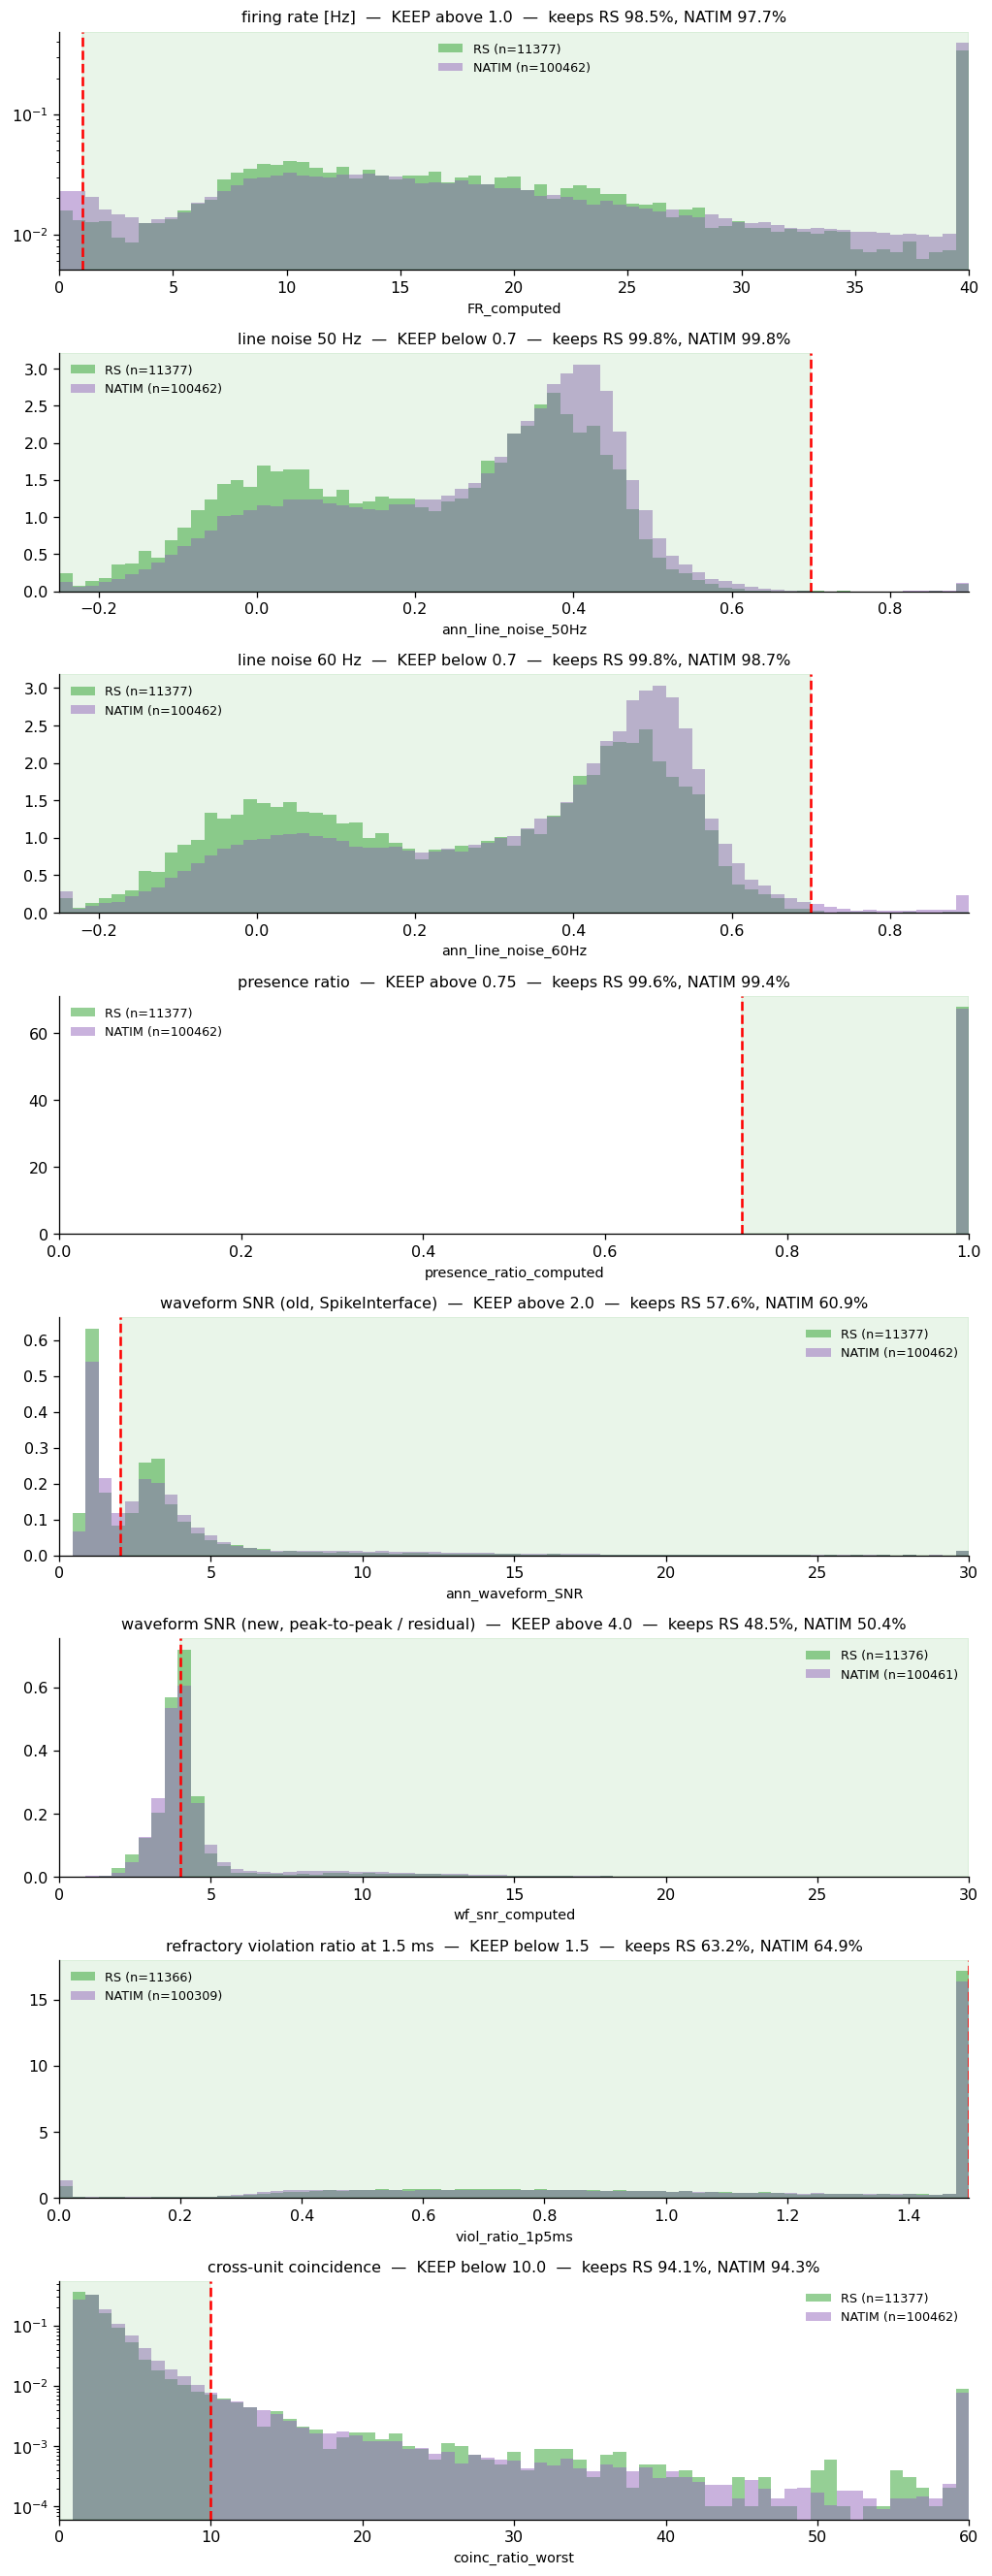

In [6]:
fig, axes = plt.subplots(len(CRIT), 1, figsize=(9, 2.9*len(CRIT)), dpi=115)
axes = np.atleast_1d(axes)
for ax, (col, (direc, th, name)) in zip(axes, CRIT.items()):
    vals = {tr: d[col].replace([np.inf,-np.inf], np.nan).dropna()
            for tr, d in DATA.items() if col in d.columns}
    vals = {k: v for k, v in vals.items() if len(v)}
    if not vals:
        ax.axis('off'); continue
    lo, hi = RANGES[col]
    bins = np.linspace(lo, hi, 70)
    for tr, v in vals.items():
        ax.hist(np.clip(v, lo, hi), bins=bins, alpha=0.5, density=True,
                color=COL[tr], label=f'{tr} (n={len(v)})')
    ax.axvline(th, color='r', ls='--', lw=1.6)
    ax.axvspan(lo if direc == 'below' else th,
               th if direc == 'below' else hi,
               color='tab:green', alpha=0.10)
    pct = {tr: 100*((v <= th) if direc == 'below' else (v >= th)).mean()
           for tr, v in vals.items()}
    ax.set_title(f'{name}  —  KEEP {direc} {th}  —  keeps ' +
                 ', '.join(f'{t} {p:.1f}%' for t, p in pct.items()), fontsize=10)
    ax.set_xlabel(col, fontsize=9); ax.set_xlim(lo, hi)
    ax.legend(fontsize=8, frameon=False)
    if col in ('coinc_ratio_worst', 'wf_shape_pc1_modesep', 'FR_computed'):
        ax.set_yscale('log')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

### 3.2 Reported but not applied

`wf_shape_pc1_modesep` detects clusters containing more than one spike shape.
It is computed and stored, but is not used to remove units. The distribution is
shown here with a reference line at the value that would have been used, so the
effect of adding it later can be judged.

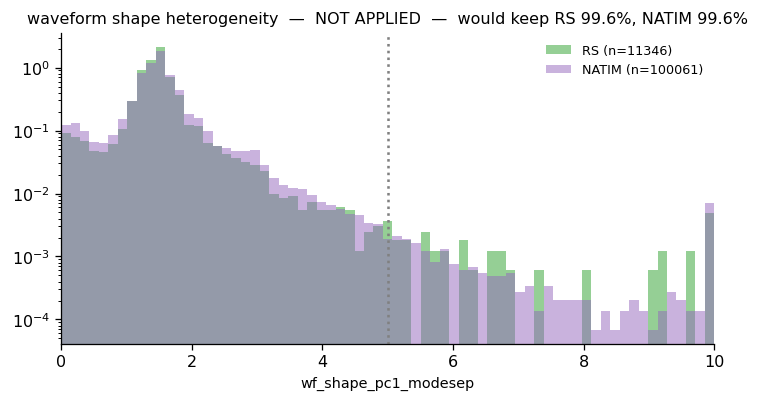

RS: wf_shape_pc1_modesep would keep 99.3% on its own (NaN 0.3%)
NATIM: wf_shape_pc1_modesep would keep 99.2% on its own (NaN 0.4%)


In [7]:
fig, axes = plt.subplots(1, len(REPORTED), figsize=(6.5*len(REPORTED), 3.6), dpi=115)
axes = np.atleast_1d(axes)
for ax, (col, (direc, th, name)) in zip(axes, REPORTED.items()):
    vals = {tr: d[col].replace([np.inf,-np.inf], np.nan).dropna()
            for tr, d in DATA.items() if col in d.columns}
    vals = {k: v for k, v in vals.items() if len(v)}
    if not vals:
        ax.axis('off'); continue
    lo, hi = RANGES.get(col, (0, 10))
    bins = np.linspace(lo, hi, 70)
    for tr, v in vals.items():
        ax.hist(np.clip(v, lo, hi), bins=bins, alpha=0.5, density=True,
                color=COL[tr], label=f'{tr} (n={len(v)})')
    ax.axvline(th, color='gray', ls=':', lw=1.6)
    pct = {tr: 100*(v <= th).mean() for tr, v in vals.items()}
    ax.set_title(f'{name}  —  NOT APPLIED  —  would keep ' +
                 ', '.join(f'{t} {p:.1f}%' for t, p in pct.items()), fontsize=10)
    ax.set_xlabel(col, fontsize=9); ax.set_xlim(lo, hi); ax.set_yscale('log')
    ax.legend(fontsize=8, frameon=False)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

for tr, d in DATA.items():
    for col, (direc, th, name) in REPORTED.items():
        if col not in d.columns: continue
        v = d[col].replace([np.inf,-np.inf], np.nan)
        would = (v <= th) & v.notna()
        extra = int((d.get('pass_filter', pd.Series(True, index=d.index)) & ~would).sum()) \
                if 'pass_filter' in d.columns else None
        print(f'{tr}: {col} would keep {100*would.mean():.1f}% on its own '
              f'(NaN {100*v.isna().mean():.1f}%)')

### 3.1 Does the rate criterion absorb the undefined units?

The refractory metric is undefined below 100 spikes and the shape metric below
200. If the rate threshold removes those units anyway, they are excluded once
for having too few spikes rather than repeatedly by metrics that could not be
computed for them.

In [8]:
for tr, d in DATA.items():
    print(f'--- {tr} ---')
    fr_ok = d['FR_computed'] >= CRIT['FR_computed'][1]
    for col, need in [('viol_ratio_1p5ms', 100), ('wf_shape_pc1_modesep', 200)]:
        if col not in d.columns: continue
        m = d[col].isna()
        print(f'{col}: {int(m.sum())} NaN of {len(d)}')
        print(f'   median spikes  NaN {d.loc[m,"n_spikes"].median():8.0f}   '
              f'defined {d.loc[~m,"n_spikes"].median():8.0f}   (needs {need})')
        print(f'   median FR      NaN {d.loc[m,"FR_computed"].median():8.3f}   '
              f'defined {d.loc[~m,"FR_computed"].median():8.3f} Hz')
        print(f'   NaN units also failing the rate criterion: '
              f'{int((m & ~fr_ok).sum())} of {int(m.sum())} '
              f'({100*(m & ~fr_ok).sum()/max(m.sum(),1):.1f}%)')
    if 'has_waveforms' in d.columns:
        m2 = d['wf_shape_pc1_modesep'].isna()
        print(f'   of the shape NaN, {int((~d.loc[m2,"has_waveforms"]).sum())} '
              f'have no waveforms at all')
    print()
print('If nearly all the NaN units also fail the rate criterion, the rate')
print('threshold is doing that work and NAN_FAILS below has little effect.')

--- RS ---
viol_ratio_1p5ms: 11 NaN of 11377
   median spikes  NaN       45   defined    20352   (needs 100)
   median FR      NaN    0.059   defined   19.305 Hz
   NaN units also failing the rate criterion: 11 of 11 (100.0%)
wf_shape_pc1_modesep: 31 NaN of 11377
   median spikes  NaN      113   defined    20397   (needs 200)
   median FR      NaN    0.108   defined   19.330 Hz
   NaN units also failing the rate criterion: 31 of 31 (100.0%)
   of the shape NaN, 1 have no waveforms at all

--- NATIM ---
viol_ratio_1p5ms: 153 NaN of 100462
   median spikes  NaN       69   defined    21680   (needs 100)
   median FR      NaN    0.065   defined   20.356 Hz
   NaN units also failing the rate criterion: 153 of 153 (100.0%)
wf_shape_pc1_modesep: 401 NaN of 100462
   median spikes  NaN      121   defined    21733   (needs 200)
   median FR      NaN    0.114   defined   20.400 Hz
   NaN units also failing the rate criterion: 401 of 401 (100.0%)
   of the shape NaN, 1 have no waveforms at all

I

## 4. Rate confounding

Refractory violations scale with the square of the firing rate, so a threshold
on the violation ratio can act as a rate filter. Worth knowing how much.

In [9]:
cols = [c for c in CRIT if c != 'FR_computed']
rows = []
for tr, d in DATA.items():
    for c in cols:
        if c not in d.columns: continue
        v = d[[c,'FR_computed']].replace([np.inf,-np.inf], np.nan).dropna()
        if len(v) < 100: continue
        rows.append({'condition': tr, 'column': c,
                     'rho_vs_FR': round(stats.spearmanr(
                         v[c], v['FR_computed']).statistic, 3)})
df_conf = pd.DataFrame(rows).pivot(index='column', columns='condition',
                                   values='rho_vs_FR')
print('Spearman rho against firing rate:')
print(df_conf.to_string())
print()
print('|rho| above about 0.5 means the criterion is substantially a rate filter.')

# what each threshold does to the median rate of the survivors
rows = []
for tr, d in DATA.items():
    med_all = d['FR_computed'].median()
    for c, (direc, th, _) in CRIT.items():
        if c not in d.columns: continue
        v = d[c].replace([np.inf,-np.inf], np.nan)
        ok = ((v <= th) if direc == 'below' else (v >= th)) & v.notna()
        rows.append({'condition': tr, 'column': c,
                     'med_FR_all': round(med_all, 3),
                     'med_FR_kept': round(d.loc[ok,'FR_computed'].median(), 3),
                     'shift': round(d.loc[ok,'FR_computed'].median()-med_all, 3)})
print()
print('shift in the median firing rate of survivors, per criterion:')
print(pd.DataFrame(rows).pivot(index='column', columns='condition',
                               values='shift').to_string())

Spearman rho against firing rate:
condition                NATIM     RS
column                               
ann_line_noise_50Hz      0.217  0.348
ann_line_noise_60Hz      0.257  0.363
ann_waveform_SNR         0.035  0.160
coinc_ratio_worst       -0.279 -0.130
presence_ratio_computed  0.281  0.238
viol_ratio_1p5ms         0.029  0.134
wf_snr_computed         -0.239 -0.278

|rho| above about 0.5 means the criterion is substantially a rate filter.

shift in the median firing rate of survivors, per criterion:
condition                NATIM     RS
column                               
FR_computed              0.482  0.239
ann_line_noise_50Hz     -0.013 -0.018
ann_line_noise_60Hz     -0.108 -0.012
ann_waveform_SNR         3.020  3.553
coinc_ratio_worst        0.824  0.472
presence_ratio_computed  0.107  0.057
viol_ratio_1p5ms         0.412 -1.648
wf_snr_computed         -3.803 -4.290


## 5. Combined yield

All seven criteria together. `NAN_FAILS` decides whether a missing value counts
as failing; section 3.1 shows how much this matters once the rate threshold is
applied.

In [10]:
NAN_FAILS = True

for tr, d in DATA.items():
    print(f'===== {tr}: {len(d)} units =====')
    flags = pd.DataFrame(index=d.index)
    for col, (direc, th, name) in CRIT.items():
        if col not in d.columns:
            print(f'   {col:26s} ABSENT'); continue
        v = d[col].replace([np.inf,-np.inf], np.nan)
        ok = (v <= th) if direc == 'below' else (v >= th)
        flags[col] = (ok & v.notna()) if NAN_FAILS else (ok | v.isna())
        print(f'   {col:26s} {direc:5s} {th:<6} keeps {100*flags[col].mean():5.1f}%  '
              f'(NaN {100*v.isna().mean():4.1f}%)')
    allpass = flags.all(axis=1)
    label = f"ALL {len(flags.columns)}"
    print(f'   {label:26s} {"":12s} keeps {100*allpass.mean():5.1f}%  '
          f'({int(allpass.sum())} units)')
    print(f'   median FR {d["FR_computed"].median():.3f} -> '
          f'{d.loc[allpass,"FR_computed"].median():.3f} Hz')
    print()
    print('   uniquely removed by each criterion, among those passing the rest:')
    for c in flags.columns:
        others = flags[[x for x in flags.columns if x != c]].all(axis=1)
        print(f'      {c:26s} {int((others & ~flags[c]).sum()):6d}')
    print()
    d['pass_filter'] = allpass
    for c in flags.columns:
        d[f'pass_{c}'] = flags[c]

===== RS: 11377 units =====
   FR_computed                above 1.0    keeps  98.5%  (NaN  0.0%)
   ann_line_noise_50Hz        below 0.7    keeps  99.8%  (NaN  0.0%)
   ann_line_noise_60Hz        below 0.7    keeps  99.8%  (NaN  0.0%)
   presence_ratio_computed    above 0.75   keeps  99.6%  (NaN  0.0%)
   ann_waveform_SNR           above 2.0    keeps  57.6%  (NaN  0.0%)
   wf_snr_computed            above 4.0    keeps  48.5%  (NaN  0.0%)
   viol_ratio_1p5ms           below 1.5    keeps  63.1%  (NaN  0.1%)
   coinc_ratio_worst          below 10.0   keeps  94.1%  (NaN  0.0%)
   ALL 8                                   keeps  21.6%  (2460 units)
   median FR 19.292 -> 16.772 Hz

   uniquely removed by each criterion, among those passing the rest:
      FR_computed                    49
      ann_line_noise_50Hz             7
      ann_line_noise_60Hz            15
      presence_ratio_computed         0
      ann_waveform_SNR             1442
      wf_snr_computed              1146
      v

In [11]:
# per animal and per recording, to check the filter is not concentrated
for tr, d in DATA.items():
    print(f'--- {tr} ---')
    print(d.groupby('monkey')['pass_filter'].agg(['size','sum','mean']).round(3).to_string())
    g = d.groupby(['monkey','date'])['pass_filter'].mean()
    print(f'   per recording: median {g.median():.3f}, '
          f'range {g.min():.3f} to {g.max():.3f}')
    print()

--- RS ---
        size  sum   mean
monkey                  
F       3454  953  0.276
L       5371  957  0.178
N       2552  550  0.216
   per recording: median 0.207, range 0.168 to 0.284

--- NATIM ---
         size    sum   mean
monkey                     
F       39949  10071  0.252
N       60513  14876  0.246
   per recording: median 0.249, range 0.229 to 0.268



## 7. Mutual coincidence pairs

A mutual pair, where each unit is the other's most coincident partner, is
usually one neuron split in two by the four-channel sorting. Dropping both loses
a real neuron, so the file-writing step should keep one. Reported here rather
than folded into the threshold.

In [12]:
for tr, d in DATA.items():
    if 'coinc_mutual' not in d.columns: continue
    mut = d[d['coinc_mutual'] & (d['coinc_ratio_worst'] > 10)]
    print(f'{tr}: {len(mut)} units in a mutual pair with ratio > 10 '
          f'({len(mut)//2} pairs)')
    if len(mut):
        both_pass = mut['pass_filter'].sum() if 'pass_filter' in mut else np.nan
        print(f'   of these, {int(both_pass)} currently pass the filter')
        print('   by array:')
        print('     ' + mut.groupby('array').size().to_string().replace('\n','\n     '))
    print()

RS: 442 units in a mutual pair with ratio > 10 (221 pairs)
   of these, 0 currently pass the filter
   by array:
     array
     1     41
     2     14
     3     31
     4      9
     5     20
     6     23
     7     24
     8     18
     9     36
     10    18
     11    32
     12    10
     13    26
     14    47
     15    40
     16    53

NATIM: 3569 units in a mutual pair with ratio > 10 (1784 pairs)
   of these, 0 currently pass the filter
   by array:
     array
     1     654
     2      74
     3     318
     4      59
     5      82
     6     330
     7     159
     8     241
     9     362
     10     93
     11    356
     12     61
     13    192
     14    115
     15    235
     16    238



## 8. Export

In [13]:
OUT = f'{DF_FOLDER}/filter_metrics_chosen'
ensure_dir_exists(OUT)
with open(f'{OUT}/thresholds.pkl', 'wb') as f:
    pickle.dump({'criteria': {c: (v[0], v[1]) for c, v in CRIT.items()},
                 'nan_fails': NAN_FAILS}, f)
for tr, d in DATA.items():
    keep = (['monkey','date','array','cell_name','train_order','Electrode_ID',
             'n_spikes','FR_computed','pass_filter','coinc_mutual',
             'coinc_partner_name','coinc_ratio_worst']
            + [f'pass_{c}' for c in CRIT if f'pass_{c}' in d.columns])
    keep = [c for c in dict.fromkeys(keep) if c in d.columns]
    d[keep].to_pickle(f'{OUT}/unit_decisions_{tr}.pkl')
    print(f'{tr}: {int(d["pass_filter"].sum())} of {len(d)} units pass '
          f'({100*d["pass_filter"].mean():.1f}%)')
print()
print('written to', OUT)
print('These decision files are what the nix-writing script will read.')

RS: 2460 of 11377 units pass (21.6%)
NATIM: 24947 of 100462 units pass (24.8%)

written to /CSNG/studekat/ripple_paper_clean_copy/dataframes/filter_metrics_chosen
These decision files are what the nix-writing script will read.


## Notes

**Order matters.** The firing rate criterion is applied first because it removes
the units for which the refractory and shape metrics are undefined. Without it
those units fail three criteria for one underlying reason, and the
uniquely-removed column misattributes spike-count exclusions to contamination.

**The waveform shape metric is reported but not applied.** It is computed,
plotted in section 3.2 and stored in the filtered files, so it remains available
as a diagnostic and can be added as a criterion later without recomputation.

**`viol_ratio_1p5ms` replaces `viol_ratio_min`.** The minimum over a grid
starting at 1 ms was zero for essentially every unit, because almost no unit has
an interval in that narrow window. The value at the conventional 1.5 ms window
behaves sensibly and matches the synthetic calibration.

**Compare RS against NATIM in section 3.** These metrics measure sorting quality
rather than brain state, so the distributions should broadly agree.
`coinc_ratio_worst` is the expected exception, since units driven by the same
stimulus are genuinely more synchronous.

**Watch the rate shift in section 4.** A criterion that moves the median firing
rate substantially is selecting on rate, which matters because the unit classes
compared later differ in rate.

**Mutual pairs need a different remedy** and are reported separately in section
6: keep one rather than drop both.

**The two SNR thresholds are absolute, on different scales.**
`ann_waveform_SNR` and `wf_snr_computed` measure different things
(background-noise-relative amplitude vs. waveform-consistency-relative
amplitude - see section 2 note), so a threshold of 2.0 on one and 4.0 on the
other is not "stricter" or "looser" in any comparable sense - each is just
what that metric's own distribution calls reasonable. Section 6 checks
whether running both criteria together is actually buying anything beyond
what one alone would do, and whether the disagreement between them
concentrates in a specific waveform class.